# Preface

Firstly, I want to thank Xichao Wang (https://www.kaggle.com/sheepwang), whose code was my work basis. And I learn a lot from the communication with Xichao Wang via email. <br>
Base on the code of Xichao Wang, I balance the data by using SMOTE and fine-tuning some parameters such as ***conf*** and ***iou-thres*** in detect.py. <br>
Secondly, I want to thank my teammate jordon2000 (https://www.kaggle.com/jordon2000), who provided great effort for coding support and GPU resource.<br>
Even though this is a competition, but the original target given by Professor Mu Li is that we can communicate here together, and learn from each other. I hope that through this platform, we can learn a lot from others.<br>
There are so many excellent talents here that I can learn how to code from scratch. I hope that we can further communicate and learn from each other. 

<span style="color: #E45D00; font-family: Segoe UI; font-size: 1.9em; font-weight: 300;">Overview</span>

&nbsp;&nbsp;✅Imbalanced Data Processing<br>
&nbsp;&nbsp;✅Experience of using YOLOv5<br>
&nbsp;&nbsp;✅Train the YOLOv5 model<br>
&nbsp;&nbsp;✅Inference and detect cowboy outfits objects<br>
&nbsp;&nbsp;✅Make Submission<br>

    

# Imbalanced Data Processing

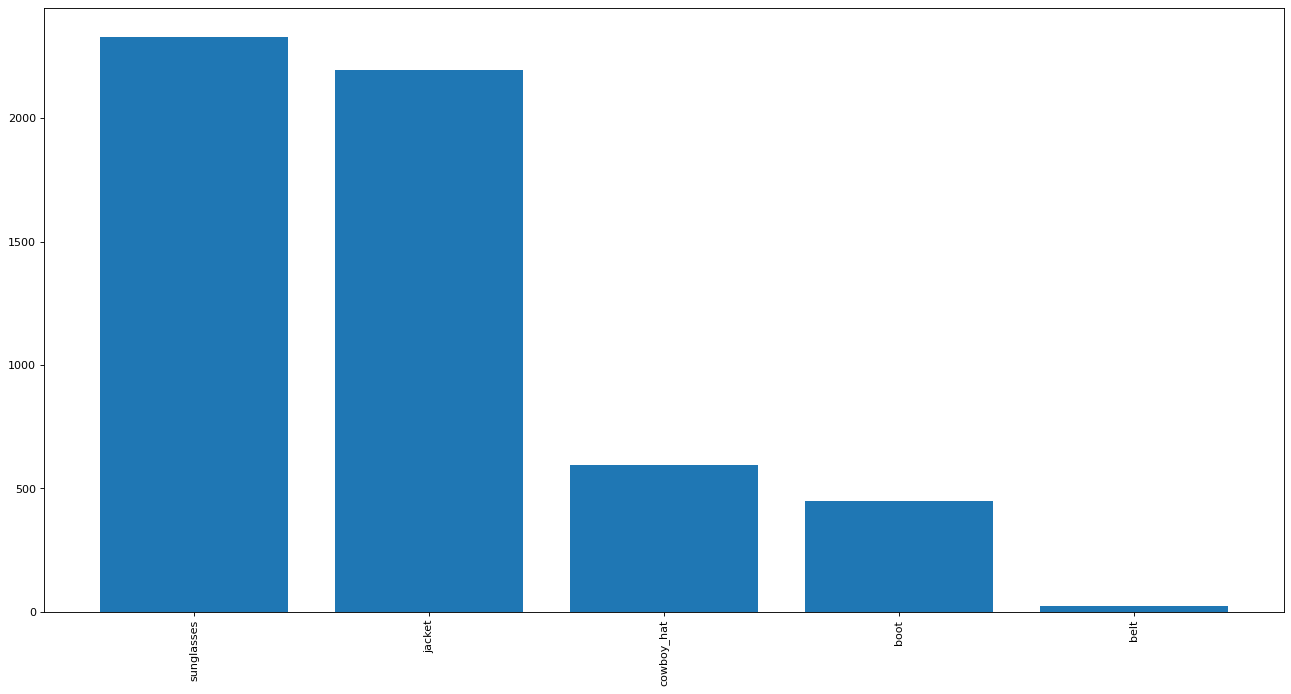

We can see from the above graph, that the distribution of category data is extremely imbalanced in this competition. Actually, in the training data, there are only 25 'Belt' category bboxes, while the 'Sunglasses' and 'Jacket' are in all more than 2000 bboxes. <br>
So it's a big challege for us to do machine learning and model training.

In [1]:
#View the distributio of categories in traning data
import json
from collections import Counter
json_file_path = './data/train.json'
data = json.load(open(json_file_path, 'r'))
dict_cat = {}
for cat in data["categories"]:
    dict_cat[cat["id"]]= cat["name"]
list_cat = []
for ann in data["annotations"]:
    list_cat.append(dict_cat[ann["category_id"]])
Counter(list_cat)

Counter({'sunglasses': 2330,
         'jacket': 2195,
         'cowboy_hat': 595,
         'boot': 449,
         'belt': 25})

In [2]:
data['images']

[{'id': 9860841628484337660,
  'file_name': '88d8bf3754317ffc.jpg',
  'neg_category_ids': [434],
  'pos_category_ids': [69, 161, 216, 277, 433],
  'width': 1024,
  'height': 681,
  'source': 'OpenImages'},
 {'id': 15984033263460081658,
  'file_name': 'ddd2b190ea90dffa.jpg',
  'neg_category_ids': [],
  'pos_category_ids': [45, 69, 277, 434],
  'width': 768,
  'height': 1024,
  'source': 'OpenImages'},
 {'id': 76077631043502082,
  'file_name': '010e4833cdb38002.jpg',
  'neg_category_ids': [308, 333, 404, 584],
  'pos_category_ids': [35, 69, 106, 228, 433, 502, 567],
  'width': 1024,
  'height': 683,
  'source': 'OpenImages'},
 {'id': 18065680256228130812,
  'file_name': 'fab6307a1a43fffc.jpg',
  'neg_category_ids': [514],
  'pos_category_ids': [69, 216, 228, 277, 333, 433, 502],
  'width': 683,
  'height': 1024,
  'source': 'OpenImages'},
 {'id': 9491379842992996352,
  'file_name': '83b827ae01e68000.jpg',
  'neg_category_ids': [40, 224, 253],
  'pos_category_ids': [15,
   69,
   148,
   

In [3]:
data['annotations']

[{'id': 12550146,
  'image_id': 15526467552013451612,
  'freebase_id': '/m/017ftj',
  'category_id': 1034,
  'iscrowd': False,
  'bbox': [102.49, 181.12, 137.08, 97.92],
  'area': 13423.09},
 {'id': 9764874,
  'image_id': 12017556593931260822,
  'freebase_id': '/m/025rp__',
  'category_id': 318,
  'iscrowd': False,
  'bbox': [284.8, 297.6, 252.8, 192.0],
  'area': 48537.65},
 {'id': 13729810,
  'image_id': 17157301591781950087,
  'freebase_id': '/m/025rp__',
  'category_id': 318,
  'iscrowd': False,
  'bbox': [431.36, 277.25, 471.04, 314.39],
  'area': 148089.55},
 {'id': 13959212,
  'image_id': 17494374403857745282,
  'freebase_id': '/m/017ftj',
  'category_id': 1034,
  'iscrowd': False,
  'bbox': [195.76, 237.59, 363.09, 85.33],
  'area': 30983.2},
 {'id': 12910638,
  'image_id': 15979914912395313233,
  'freebase_id': '/m/01b638',
  'category_id': 131,
  'iscrowd': False,
  'bbox': [263.04, 368.64, 182.4, 238.72],
  'area': 43542.48},
 {'id': 12910640,
  'image_id': 15979914912395313

There are 3 kinds of techniques to deal with imbalanced data: <br>
* under-sampling
* over-sampling
* Customs Loss Function


In this notebook, I will apply the second technique to inflate the training data to reduce the bias from the imbalanced dataset. But firstly let me briefly introduce the resampling techniques.<br>
1. Under-sampling<br>
It means balances the dataset by reducing the size of the abundant class. This method is used when quantity of data is sufficient. By keeping all samples in the rare class and randomly selecting an equal number of samples in the abundant class, a balanced new dataset can be retrieved for further modelling.<br>
2. Over-sampling<br>
On the contrary, oversampling is used when the quantity of data is insufficient. It tries to balance dataset by increasing the size of rare samples. Rather than getting rid of abundant samples, new rare samples are generated by using e.g. repetition, bootstrapping or SMOTE (Synthetic Minority Over-Sampling Technique) <br>
3. Customs Loss Function<br>
It means we can change weight of loss to account for imbalance. Taking log function as an example:<br>
$–(x*logp)+(1-x)log⁡(1-p))$, in which x is true label, p means prediction
While the custom loss function transfers the log function into:<br>
$A*x*log⁡(p)+(1-x)log⁡(1-p)$,
$A$ means how is the ratio we want to balance the dataset. So for the imbalaced dataset, we should relatively change our loss function to make our prediction more precisely.

Note that there is no absolute advantage of one resampling method over another. Application of these two methods depends on the use case it applies to and the dataset itself. A combination of over- and under-sampling is often successful as well.
In this competition, I only apply over-sampling, which means I amplify the least data based on the quantities of the biggest dataset. I repeated the least dataset over and over to reach the largest dataset by using SMOTE.

In [5]:
# Firstly, we must import some libs
import os
import numpy as np
import pandas as pd
import gc
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import yaml
from shutil import copyfile
import matplotlib.pyplot as plt

import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

Matplotlib is building the font cache; this may take a moment.


##### In the following function ***train_test_split***, the parameter ***stratify*** can split all categories (such as 'Belt', 'Jacket') in this parameter into train set and test set respectly.

In [6]:
# Split train dataset and test dataset according to annotation_id
X = pd.DataFrame(data["annotations"])
Y = pd.DataFrame(X["category_id"])
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.1,random_state=1,stratify = Y)
Counter(list(y_train["category_id"]))

Counter({1034: 2097, 588: 1975, 318: 535, 131: 404, 87: 23})

Then, we will get the balanced training data by using SMOTE. And each category will has the same number of annotations.

In [10]:
# Using the SOMTE to inflate the imbanlanced data, such as 'Belt'
x_train_only_id = pd.DataFrame(x_train['id'])
X_SMOTE, Y_SMOTE = SMOTE().fit_resample(x_train_only_id.values,y_train.values)
Counter(Y_SMOTE)

Counter({np.int64(588): 2097,
         np.int64(1034): 2097,
         np.int64(131): 2097,
         np.int64(318): 2097,
         np.int64(87): 2097})

In [9]:
X_SMOTE.shape

(10485, 1)

### Now the numbers of all categories training data are the same and balanced.

# Experience of using YOLOv5 

I have tried all models including yolov5 S M L X with default hyperparameters, with trainning epochs are all 100. However, the best result in these models was from yolov5 M(yolov5m.pt). And even I enlarged the epoch times to 200 with model yolov5 M, the result was worsened than 100 epochs training in model yolov5 M. 

In [ ]:
# Let's install Yolov5 to exploring a wonderful trip 
# %cd /kaggle/working
!git clone https://github.com/ultralytics/yolov5
%cd /kaggle/working/yolov5
%pip install -r requirements.txt

/kaggle/working
Cloning into 'yolov5'...
remote: Enumerating objects: 8754, done.
remote: Counting objects: 100% (468/468), done.
remote: Compressing objects: 100% (277/277), done.
remote: Total 8754 (delta 300), reused 318 (delta 191), pack-reused 8286
Receiving objects: 100% (8754/8754), 9.67 MiB | 15.85 MiB/s, done.
Resolving deltas: 100% (6040/6040), done.
/kaggle/working/yolov5
Note: you may need to restart the kernel to use updated packages.


# Data format transfering (from COCO to YOLO)

In [ ]:
# Storing some dictionaries, {annotation_id:nubers}; {image_id:images in train.json}
df_annid = pd.DataFrame(X_SMOTE,columns=['ann_id'])
print(df_annid.head())
# Storing the inflated annotations
dict_annid = {} # 统计每个id被重采样了多少次
for i,row in df_annid.iterrows():
    annid = row['ann_id']
    if annid in dict_annid:
        dict_annid[annid] += 1
    else:
        dict_annid[annid] = 1
# Storing the imageid and its json data
dict_imgid = {}
for img in data["images"]:
    id = img['id']
    dict_imgid[id] = img

     ann_id
0  14510946
1  10104124
2   3649978
3   2544182
4  12952933


In [11]:
# Transfer the categories to continuous ids
cate_id_map = {}
for i, category in enumerate(data['categories']):     
    cate_id_map[category['id']] = i
    #id_cat[i] = category['id']
cate_id_map

{87: 0, 1034: 1, 131: 2, 318: 3, 588: 4}

In [12]:
# convert the bounding box from COCO to YOLO format.
def cc2yolo_bbox(img_width, img_height, bbox):
    dw = 1. / img_width
    dh = 1. / img_height
    x = bbox[0] + bbox[2] / 2.0
    y = bbox[1] + bbox[3] / 2.0
    w = bbox[2]
    h = bbox[3]
 
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return (x, y, w, h)

In [14]:
# Create the path for storing the txt files for yolov5
yolo_anno_path = 'training/yolo_anno/'
if not os.path.exists(yolo_anno_path):
    os.makedirs(yolo_anno_path)

In [15]:
# Building the train and validation images list
dict_imgid_count = {} # this dictionary records how many images are the same
f = open('/kaggle/working/train_valid.csv','w')
f.write('id,file_name,split\n')
for i in tqdm(range(len(data['annotations']))):
    annid = data['annotations'][i]['id']
    img_id = data['annotations'][i]['image_id']
    filename = dict_imgid[img_id]['file_name']
    yolo_txt_name = filename.split('.')[0] + '.txt' #remove .jpg
    img_width = dict_imgid[img_id]['width']
    img_height = dict_imgid[img_id]['height']
    if annid in dict_annid:
        temp_count = 1
        if img_id in dict_imgid_count:
            dict_imgid_count[img_id] += 1
            temp_count = dict_imgid_count[img_id]
        else:
            dict_imgid_count[img_id] = 1        
        arr = str(filename).split('.')
        filename = arr[0] + '_' + str(temp_count) + '.' + arr[1]
        f.write('{},{},train\n'.format(img_id, filename))    
    
    yolo_txt_file = open(os.path.join(yolo_anno_path, yolo_txt_name), 'w')    
    for anno in data['annotations']:
        if anno['image_id'] == img_id:
            yolo_bbox = cc2yolo_bbox(img_width, img_height, anno['bbox']) # "bbox": [x,y,width,height]        
            yolo_txt_file.write('{} {} {} {} {}\n'.format(cate_id_map[anno['category_id']], yolo_bbox[0], yolo_bbox[1], yolo_bbox[2], yolo_bbox[3]))
    yolo_txt_file.close()

# write validation files into the file train.csv
for i,row in x_test.iterrows():
    img_id = row['image_id']
    filename = dict_imgid[img_id]['file_name']
    f.write('{},{},valid\n'.format(img_id, filename))

f.close()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/train_valid.csv'

In [ ]:
# Then we got the training and tesing dataframe
df = pd.read_csv('/kaggle/working/train_valid.csv')
print(df)

                        id               file_name  split
0     15526467552013451612  d77917f9ce64015c_1.jpg  train
1     12017556593931260822  a6c6f00ce96d1396_1.jpg  train
2     17157301591781950087  ee1afae4fa684287_1.jpg  train
3     17494374403857745282  f2c880d4c5a08582_1.jpg  train
4     15979914912395313233  ddc40ff2964a4051_1.jpg  train
...                    ...                     ...    ...
5608   1760080288783192349    186d0fb28516d11d.jpg  valid
5609  13071488121744982452    b5674130e65901b4.jpg  valid
5610   7124248788343262427    62de6a86f0b50cdb.jpg  valid
5611  12142905833432419214    a884448506c20b8e.jpg  valid
5612    114826298118769343    0197f1e8e63e0abf.jpg  valid

[5613 rows x 3 columns]


# Preparing txt files and image files for YOLOv5

In [ ]:
# Preparing the data and structure directories for Yolov5
os.makedirs('/kaggle/working/training/images/train', exist_ok=True)
os.makedirs('/kaggle/working/training/images/valid', exist_ok=True)
#
os.makedirs('/kaggle/working/training/labels/train', exist_ok=True)
os.makedirs('/kaggle/working/training/labels/valid', exist_ok=True)

In [ ]:
# copy the image files and annotations txt files to relevant folders
for i in tqdm(range(len(df))):
    row = df.loc[i]
    #name = row.file_name.split('.')[0]
    
    name_count = row.file_name.split('.')[0]
    name = name_count.split('_')[0]
    #if i<10:
    #    print(name)
    if row.split == 'train':        
        copyfile(f'/kaggle/input/cowboyoutfits/images/{name}.jpg', f'/kaggle/working/training/images/train/{name_count}.jpg')
        copyfile(f'/kaggle/working/training/yolo_anno/{name}.txt', f'/kaggle/working/training/labels/train/{name_count}.txt')
    else:        
        copyfile(f'/kaggle/input/cowboyoutfits/images/{name}.jpg', f'/kaggle/working/training/images/valid/{name}.jpg')
        copyfile(f'/kaggle/working/training/yolo_anno/{name}.txt', f'/kaggle/working/training/labels/valid/{name}.txt')

100%|██████████| 5613/5613 [00:37<00:00, 150.19it/s]


# Train the YOLOv5 model

In [ ]:
# Firstly we create the yaml file
data_yaml = dict(
    train = '/kaggle/working/training/images/train/',
    val = '/kaggle/working/training/images/valid/',
    nc = 5,
    names = ['belt', 'sunglasses', 'boot', 'cowboy_hat', 'jacket']
)

# we will make the file under the yolov5/data/ directory.
with open('/kaggle/working/yolov5/data/data.yaml', 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=True)
    
%cat /kaggle/working/yolov5/data/data.yaml # show your YAML file

{names: [belt, sunglasses, boot, cowboy_hat, jacket], nc: 5, train: /kaggle/working/training/images/train/,
  val: /kaggle/working/training/images/valid/}


In [ ]:
# Before GO TRAIN, wandb must be set up and run
# Install W&B 
##!pip install -q --upgrade wandb
# Login with token, follow with the guide
##import wandb
##wandb.login()

# For simply showing the code, I turn off W&B
import wandb
!wandb off

W&B offline, running your script from this directory will only write metadata locally.


### Choose some parameters for training
> ##### For showing the code example, I only train one time. 
> ##### In my best training parameters, batch_size=24, epochs=100 and model=yolov5m.pt

In [ ]:
# For showing the example code, I only select yolov5s model and 1 epoch to run.
BATCH_SIZE = 16
EPOCHS = 1 
MODEL = 'yolov5s.pt' # this specify the model for training, you can use yolov5s.pt, yolov5l.pt, yolov5x.pt, etc.

In [ ]:
# GO TRAIN
!python train.py --batch {BATCH_SIZE} \
                 --epochs {EPOCHS} \
                 --data data.yaml \
                 --weights {MODEL} \
                 --save_period 1\
                 --project cowboy-detection\
                 --name exp

train: weights=yolov5s.pt, cfg=, data=data.yaml, hyp=data/hyps/hyp.scratch.yaml, epochs=1, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, adam=False, sync_bn=False, workers=8, project=cowboy-detection, entity=None, name=exp, exist_ok=False, quad=False, linear_lr=False, label_smoothing=0.0, upload_dataset=False, bbox_interval=-1, save_period=1, artifact_alias=latest, local_rank=-1, freeze=0
github: up to date with https://github.com/ultralytics/yolov5 ✅
2021-08-08 05:46:35.485764: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2021-08-08 05:46:40.334847: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
wandb: W&B syncing is set to `offline` in this directory.  Run `wandb online` or set WANDB_MODE=on

# Inference and detect cowboy outfits objects

In [ ]:
# In the Dev phase, we will only use the valid data for predicition. 
# Don't forget change it to test data in the Final pahse.
valid_df = pd.read_csv('/kaggle/input/cowboyoutfits/valid.csv')
test_df = pd.read_csv('/kaggle/input/cowboyoutfits/test.csv')
valid_df.head()

,id,file_name
0,2817499345625518079,2719c4ba22e78fff.jpg
1,4780409558104969215,42576d2a57ba8fff.jpg
2,7518610131770248858,685778145cd18e9a.jpg
3,9535349983136256004,84545e4a09dd1004.jpg
4,15034561753984241668,d0a57e423be79004.jpg


In [ ]:
# make directory to store the validation data.
os.makedirs('/kaggle/working/inference/valid', exist_ok=True)
os.makedirs('/kaggle/working/inference/test', exist_ok=True)

In [ ]:
# copy the validation image to inference folder for detection process
for i in tqdm(range(len(valid_df))):
    row = valid_df.loc[i]    
    name = row.file_name.split('.')[0]
    copyfile(f'/kaggle/input/cowboyoutfits/images/{name}.jpg', f'/kaggle/working/inference/valid/{name}.jpg')

100%|██████████| 999/999 [00:13<00:00, 72.42it/s]


##### Here, by using {MODEL_PATH}, you could use your trained model to inference and detect objects.<br> 
However, Kaggle has made a limitation for free users, when your training time reach to 6 hours, you cannot save your notebook. And when your training time reached to 9 hours, your training will be stopped by kaggle immediately. 
##### So I only use my best trained model to show the code, and you can use your trained model or any other trained model in inference phrase.

In [ ]:
VALID_PATH = '/kaggle/working/inference/valid/'
#MODEL_PATH = '/kaggle/working/yolo/cowboy-detection/exp5/weights/best.pt'
MODEL_PATH = '/kaggle/input/bestmodelweights/exp8-m-100ep-withonesplit-best.pt'
IMAGE_PATH = '/kaggle/input/cowboyoutfits/images/'

### Amazing Detection Objects

##### Here you can change many parameter such as ***conf*** and ***iou-thres***. <br>
In my experiments, when ***conf*** changed from 0.546 to 0.005, it will improve my dev result 2-3 percent.

In [ ]:
# Let's begin the amazing time to detect the cowboy outfits objects
!python detect.py --weights {MODEL_PATH} \
                  --source {VALID_PATH} \
                  --conf 0.005 \
                  --iou-thres 0.45 \
                  --save-txt \
                  --save-conf \
                  --augment

detect: weights=['/kaggle/input/bestmodelweights/exp8-m-100ep-withonesplit-best.pt'], source=/kaggle/working/inference/valid/, imgsz=640, conf_thres=0.005, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=True, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False
image 1/999 /kaggle/working/inference/valid/0007c3f55f707547.jpg: 448x640 1 cowboy_hat, Done. (0.098s)
image 2/999 /kaggle/working/inference/valid/000d64dae0250e8b.jpg: 512x640 1 sunglasses, 2 cowboy_hats, 7 jackets, Done. (0.098s)
image 3/999 /kaggle/working/inference/valid/001848e71f5c757a.jpg: 448x640 1 cowboy_hat, Done. (0.081s)
image 4/999 /kaggle/working/inference/valid/0018a10d8a6e0dd4.jpg: 480x640 4 sunglassess, 4 jackets, Done. (0.093s)
image 5/999 /kaggle/working/inference/valid/002901902b4f8fb6.jpg: 448x640 3 jackets, D

In [ ]:
# If you have run more than one times of detect.py, 
# the name of 'exp' in the path will be changed for storing the detecting results.
PRED_PATH = '/kaggle/working/yolov5/runs/detect/exp/labels/'

# list our prediction files path
prediction_files = os.listdir(PRED_PATH)
print('Number of test images with detections: ', len(prediction_files))

Number of test images with detections:  978


# Make Submission

In [ ]:
# convert yolo to coco annotation format
def yolo2cc_bbox(img_width, img_height, bbox):
    x = (bbox[0] - bbox[2] * 0.5) * img_width
    y = (bbox[1] - bbox[3] * 0.5) * img_height
    w = bbox[2] * img_width
    h = bbox[3] * img_height
    
    return (x, y, w, h)

In [ ]:
# reverse the categories numer to the origin id
re_cate_id_map = dict(zip(cate_id_map.values(), cate_id_map.keys()))
print(re_cate_id_map)

{0: 87, 1: 1034, 2: 131, 3: 318, 4: 588}


In [ ]:
def make_submission(df, PRED_PATH, IMAGE_PATH):
    output = []
    for i in tqdm(range(len(df))):
        row = df.loc[i]
        image_id = row['id']
        file_name = row['file_name'].split('.')[0]
        if f'{file_name}.txt' in prediction_files:
            img = Image.open(f'{IMAGE_PATH}/{file_name}.jpg')
            width, height = img.size
            with open(f'{PRED_PATH}/{file_name}.txt', 'r') as file:
                for line in file:
                    preds = line.strip('\n').split(' ')
                    preds = list(map(float, preds)) #conver string to float
                    cc_bbox = yolo2cc_bbox(width, height, preds[1:-1])
                    result = {
                        'image_id': image_id,
                        'category_id': re_cate_id_map[preds[0]],
                        'bbox': cc_bbox,
                        'score': preds[-1]
                    }

                    output.append(result)
    return output

In [ ]:
sub_data = make_submission(valid_df, PRED_PATH, IMAGE_PATH)
op_pd = pd.DataFrame(sub_data)
op_pd.sample(10)

100%|██████████| 999/999 [00:01<00:00, 901.28it/s]


,image_id,category_id,bbox,score
823,12779681728249496752,318,"(423.999488, 219.99974400000002, 206.000128, 1...",0.822716
1990,15200300707316862490,1034,"(369.99987200000004, 321.99974399999996, 227.9...",0.900298
120,10066058694092460027,588,"(264.00051199999996, 427.00032, 554.999808, 33...",0.889473
878,2262210423413575287,1034,"(183.00026880000001, 235.99983049999997, 17.00...",0.408595
2062,14696351632578154024,1034,"(-3.840000000110422e-05, 321.000448, 30.0, 32.0)",0.390108
851,8819164189673268405,588,"(579.00032, 129.99963400000001, 334.999552, 47...",0.444588
129,14953981359712079261,1034,"(151.000064, 231.00013859999999, 96.0, 28.0000...",0.934144
2810,11912392936434601752,1034,"(727.9997568, 857.99936, 39.9999744, 163.00032)",0.010316
1641,9285303287768976819,588,"(-0.0002047999999916783, 421.99987200000004, 1...",0.872208
2160,11477926726099117648,131,"(510.000128, 67.999744, 248.999936, 252.000256)",0.944930


## Finally, got your submitting zip file.

In [ ]:
import zipfile 
op_pd.to_json('/kaggle/working/answer.json',orient='records')
zf = zipfile.ZipFile('/kaggle/working/sample_answer.zip', 'w')
zf.write('/kaggle/working/answer.json', 'answer.json')
zf.close()